In [11]:
import sys
print(sys.executable)

c:\ml_projects\Customer-Churn-Prediction\.venv\Scripts\python.exe


In [12]:
import xgboost

print(xgboost.__version__)

3.4.1


In [13]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [1]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [2]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression retrained successfully!")

Logistic Regression retrained successfully!


In [3]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [6]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8052594171997157
ROC-AUC: 0.8360739966143986

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8052594171997157
ROC-AUC: 0.8360739966143986

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [9]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.30 | Precision: 0.513 | Recall: 0.759 | F1: 0.612
Threshold: 0.35 | Precision: 0.545 | Recall: 0.722 | F1: 0.621
Threshold: 0.40 | Precision: 0.578 | Recall: 0.684 | F1: 0.627
Threshold: 0.45 | Precision: 0.604 | Recall: 0.631 | F1: 0.617
Threshold: 0.50 | Precision: 0.652 | Recall: 0.575 | F1: 0.611
Threshold: 0.55 | Precision: 0.670 | Recall: 0.484 | F1: 0.562
Threshold: 0.60 | Precision: 0.679 | Recall: 0.385 | F1: 0.491


In [14]:
import pandas as pd
import numpy as np

# Splitting
from sklearn.model_selection import train_test_split

# Scaling
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Save model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [16]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [23]:
print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True))

Churn
0    4130
1    1495
Name: count, dtype: int64

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [ ]:
# logistic regresstion
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [25]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8052594171997157
ROC-AUC: 0.8360739966143986

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [27]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8052594171997157, 'ROC-AUC': 0.8360739966143986}


In [28]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [29]:
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7164179104477612
ROC-AUC: 0.6343317578725586

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.46       374

    accuracy                           0.72      1407
   macro avg       0.64      0.63      0.64      1407
weighted avg       0.72      0.72      0.72      1407

Confusion Matrix:
[[836 197]
 [202 172]]


In [31]:
#Randome forest
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [32]:
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7867803837953091
ROC-AUC: 0.8172189407312691

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
[[919 114]
 [186 188]]


In [34]:
#XGboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [35]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7945984363894811
ROC-AUC: 0.838367301510061

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.72      1407
weighted avg       0.79      0.79      0.79      1407

Confusion Matrix:
[[913 120]
 [169 205]]


In [37]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
    }
])

results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
3,XGBoost,0.794598,0.838367
0,Logistic Regression,0.805259,0.836074
2,Random Forest,0.786780,0.817219
1,Decision Tree,0.716418,0.634332


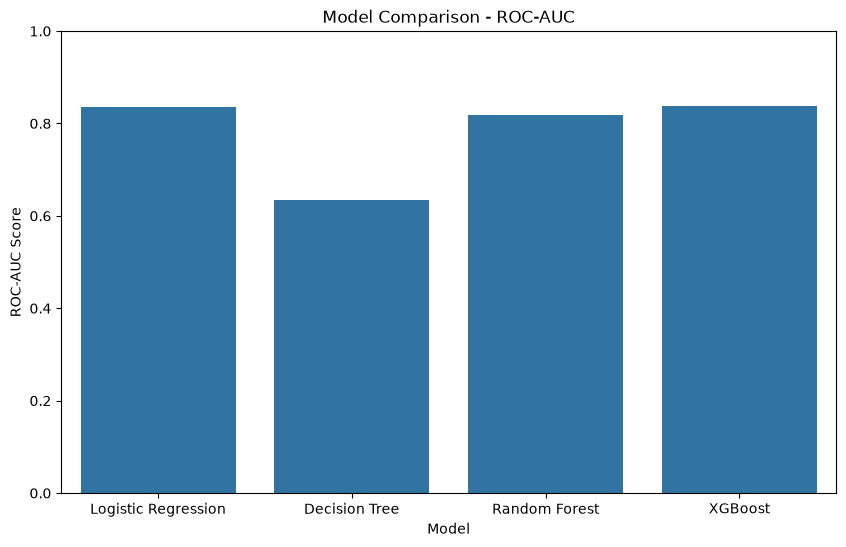

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model Comparison - ROC-AUC")
plt.ylabel("ROC-AUC Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.show()

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.30 | Precision: 0.513 | Recall: 0.759 | F1: 0.612
Threshold: 0.35 | Precision: 0.545 | Recall: 0.722 | F1: 0.621
Threshold: 0.40 | Precision: 0.578 | Recall: 0.684 | F1: 0.627
Threshold: 0.45 | Precision: 0.604 | Recall: 0.631 | F1: 0.617
Threshold: 0.50 | Precision: 0.652 | Recall: 0.575 | F1: 0.611
Threshold: 0.55 | Precision: 0.670 | Recall: 0.484 | F1: 0.562
Threshold: 0.60 | Precision: 0.679 | Recall: 0.385 | F1: 0.491


In [10]:
best_threshold = 0.40

y_pred_final = (y_prob >= best_threshold).astype(int)

print("Final threshold:", best_threshold)
print(classification_report(y_test, y_pred_final))

Final threshold: 0.4
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



In [41]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Confusion Matrix:
[[846 187]
 [118 256]]


In [42]:
print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob))

Final Accuracy: 0.783226723525231
Final ROC-AUC: 0.8360739966143986


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = {
    "Model": "Logistic Regression",
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1-Score": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

final_results

{'Model': 'Logistic Regression',
 'Threshold': 0.4,
 'Accuracy': 0.783226723525231,
 'Precision': 0.5778781038374717,
 'Recall': 0.6844919786096256,
 'F1-Score': 0.6266829865361077,
 'ROC-AUC': 0.8360739966143986}

In [44]:
final_results_df = pd.DataFrame([final_results])

final_results_df

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.4,0.783227,0.577878,0.684492,0.626683,0.836074


In [45]:
final_results_df.to_csv(
    "../data/processed/final_model_results.csv",
    index=False
)

print("Final model results saved successfully!")

Final model results saved successfully!


In [46]:
final_results_df

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.4,0.783227,0.577878,0.684492,0.626683,0.836074


In [11]:
cm = confusion_matrix(y_test, y_pred_final)

print("Final Confusion Matrix:")
print(cm)

Final Confusion Matrix:
[[846 187]
 [118 256]]


In [12]:
print("Final Metrics")
print("-------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1-Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Final Metrics
-------------------------
Accuracy : 0.783226723525231
Precision: 0.5778781038374717
Recall   : 0.6844919786096256
F1-Score : 0.6266829865361077
ROC-AUC  : 0.8360739966143986


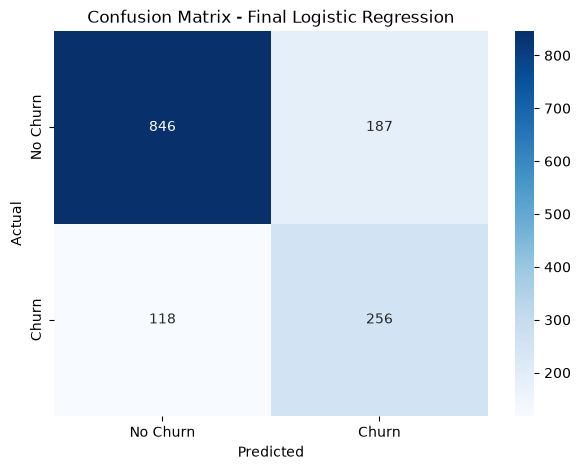

In [48]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Final Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
import joblib

joblib.dump(
    logistic_model,
    "../data/processed/logistic_regression_model.pkl"
)

joblib.dump(
    best_threshold,
    "../data/processed/churn_threshold.pkl"
)

print("Final model saved successfully!")
print("Final threshold saved successfully!")

Final model saved successfully!
Final threshold saved successfully!


In [50]:
joblib.dump(
    best_threshold,
    "../data/processed/churn_threshold.pkl"
)

print("Churn threshold saved successfully!")

Churn threshold saved successfully!


In [51]:
import os

print(os.listdir("../data/processed"))

['.gitkeep', 'churn_threshold.pkl', 'final_model_results.csv', 'logistic_regression_model.pkl', 'scaler.pkl', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


# Summary

The following models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

After comparing their performance on the test dataset, the best-performing model was selected and saved for deployment.

The saved model and scaler will be used later to build the prediction pipeline and deploy the application.